Lo primero que se hace es importar las librerias necesarias y cargar el archivo con los datos de la "NASA.csv". Esto permite trabajar con los datos de manera tabular. Despues de cargar el archivo se revisan las dimensiones de los datos para confirmar cuantas observaciones y cuantas variables tiene, lo que debe coincindir con lo que piden las instrucciones. Tambien se muestran las primeras 15 filas para ver como se ven las variables y verificar que esten completas, que tengan los nombres correctos y que no haya errores en la lectura.

In [36]:
import pandas as pd

data = pd.read_csv("NASA.csv")

print("Dimensiones dataset:", data.shape)

data.head(15)

Dimensiones dataset: (1503, 6)


,frecuencia,angulo,longitud,velocidad,espesor,presion
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
5,2500,0.0,0.3048,71.3,0.002663,125.571
6,3150,0.0,0.3048,71.3,0.002663,125.201
7,4000,0.0,0.3048,71.3,0.002663,123.061
8,5000,0.0,0.3048,71.3,0.002663,121.301
9,6300,0.0,0.3048,71.3,0.002663,119.541


Aqui se hace una separacion entre las variables independientes y dependientes. Las cinco variables predictoras corresponden a frecuencia, angulo, longitud, velocidad y espesor, mientras que la variable dependiente es presion. Luego divido el dataset en un conjunto de entrenamiento y uno de prueba utilizando la funcion "train_test_split". Esta division se hace de manera aleatoria, tambien esta el "random_state" de modo que los resultados sean reproducibles. Al final se imprimen las dimensiones de ambos para confirmar que sumenn el total de datos originales y que la division se haya hecho correctamente.

In [37]:
from sklearn.model_selection import train_test_split

x = data.drop(columns=["presion"])
y = data["presion"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

print("Dimensiones entrenamiento: ",x_train.shape, y_train.shape)
print("Dimensiones prueba: ", x_test.shape, y_test.shape)
print("Total: ", len(x_train) + len(x_test), "vs original", len(data))

Dimensiones entrenamiento:  (1052, 5) (1052,)
Dimensiones prueba:  (451, 5) (451,)
Total:  1503 vs original 1503


Uso la libreria statsmodels, que permite tener un analisis estadistico mas detallado. Primero inclui el intercepto del modelo, ya que statsmodels no lo agrega por defecto. Despues ajuste el modelo con el metodo de minimos cuadrados ordinarios (OLS) y se imprime un resumen completo con la informacion del ajuste. En esta celda aparecen los coeficientes de cada variable, sus errores estandar, los valores t y los p-values, ademas de metricas globales como R², R² ajustado y la estadisticca F del modelo. Esto hace que se pueda evaluaar tanto la clidad general del ajuste como la significancia estadistica. Para mayor claridad tambien se muestra aparte los coeficientes y  los p-values exactos, ya que el resumen a veces los redondea a 0.00

In [38]:
import statsmodels.api as sm

x_train_sm = sm.add_constant(x_train)

modelo = sm.OLS(y_train, x_train_sm).fit()

print(modelo.summary())

print("\nCoeficientes:")
print(modelo.params)

print("\nP-values:")
print(modelo.pvalues)

                            OLS Regression Results                            
Dep. Variable:                presion   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     227.9
Date:                Wed, 20 Aug 2025   Prob (F-statistic):          1.38e-164
Time:                        21:18:33   Log-Likelihood:                -3138.0
No. Observations:                1052   AIC:                             6288.
Df Residuals:                    1046   BIC:                             6318.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        132.4778      0.651    203.367      0.0

Aqui se interpreta la significancia de las variables. Con los p-values se ve cuales predictores tienen una relacion significativa con la variable dependiente, considerando el 0.05. En este caso se si existe al menos una variable significativa en el modelo. Tambien se sabe cual es la variable mas importante tomando en cuenta el coeficiente de mayor magnitud en valor absoluto, aunque se aclara que al no estandarizar las variables este criterio puede estar influido por las diferentes escalas de medida.

In [39]:
sig = modelo.pvalues[modelo.pvalues < 0.05].index.tolist()
print("Variables significativas:", sig)

var_imp = modelo.params.abs().idxmax()
print("Variable mas importante segun coeficiente:", var_imp)

Variables significativas: ['const', 'frecuencia', 'angulo', 'longitud', 'velocidad', 'espesor']
Variable mas importante segun coeficiente: espesor


En esta parte se calculan metricas para evaluar la calidad del modelo tanto entrenamiento como en validacion. Para los datos de entrenamiento se obtiene el RSE a partir del "scale" del modelo, sacando su raiz cuadrada, y tambien se reporta el R² del modelo. Para validar se genera predicciones con los datos de prueba y se calculan los residuos como la diferencia entre valores reales y valores estimados. A partir de esos residuos se obtiene el RSE en validacion y tambien se calcula el total. La comparación entre métricas de entreamiento y validación permite analizar si el modelo generaliza bien o si muestra señales de sobreajuste, lo cual ocurre cuando el desempeño es mucho mejor en entrenamiento que en prueba

In [40]:
import numpy as np

rse_train = np.sqrt(modelo.scale)
r2_train = modelo.rsquared

print("Entrenamiento: ")
print("RSE: ", rse_train)
print("R^2:", r2_train)

x_test_sm = sm.add_constant(x_test)
y_pred = modelo.predict(x_test_sm)

resi= y_test - y_pred
rse_test = np.sqrt(np.sum(resi**2) / (len(y_test) - x_test.shape[1] - 1))

ss_tot = np.sum((y_test - np.mean(y_test))**2)
ss_res = np.sum(resi**2)
r2_test = 1 -(ss_res / ss_tot)

print("\nValidacion:")
print("RSE:", rse_test)
print("R^2:", r2_test)

Entrenamiento: 
RSE:  4.791436345798011
R^2: 0.5214416938715561

Validacion:
RSE: 4.89971888411482
R^2: 0.4982726587937798


Se genera un diagrama de dispersión donde el eje x se colocan los valores reales de la presión y en el eje Y los valores predichhos por el modelo. Tambien se agrega una linea de referencia con pendiente, que representa los 45° la situacion ideal en la cual el modelo predice perfectamente los valores reales. Entre mas cerca estén los puntos de esta linea mejor es la capacidad de predecir el modelo. Si los puntos se dispersan mucho, significa que el modelo tiene errores. Esta grafica sirve como una evaluacion cualitativa que complementa los numeros de R² y RSE, ya que permite ver visualmente cómo son las predicciones comparados con los reales. 

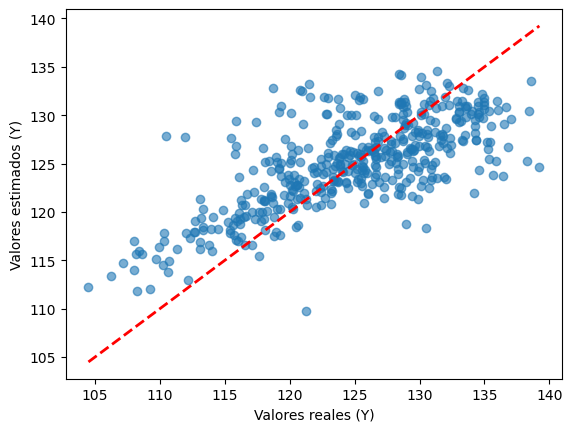

In [42]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],"r--", lw=2)
plt.xlabel("Valores reales (Y)")
plt.ylabel("Valores estimados (Y)")
plt.show()